In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    RocCurveDisplay,
)

from sklearn.inspection import permutation_importance

SEED = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [23]:
PROJECT_FOLDER = "/content/drive/MyDrive/Dataset_A_Hackathon"

TRAIN_FILE = os.path.join(
    PROJECT_FOLDER,
    "dataset_A_training(3).csv"
)

TEST_FILE = os.path.join(
    PROJECT_FOLDER,
    "dataset_A_testing(3).csv"
)

OUTPUT_FOLDER = os.path.join(
    PROJECT_FOLDER,
    "random_forest_outputs"
)

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print("Training file:", TRAIN_FILE)
print("Testing file:", TEST_FILE)
print("Output folder:", OUTPUT_FOLDER)

Training file: /content/drive/MyDrive/Dataset_A_Hackathon/dataset_A_training(3).csv
Testing file: /content/drive/MyDrive/Dataset_A_Hackathon/dataset_A_testing(3).csv
Output folder: /content/drive/MyDrive/Dataset_A_Hackathon/random_forest_outputs


In [8]:
train_df = pd.read_csv("/content/drive/MyDrive/dataset_A_training.csv")
test_df = pd.read_csv("/content/drive/MyDrive/dataset_A_testing.csv")

In [9]:
print("Training dataset shape:", train_df.shape)
print("Testing dataset shape:", test_df.shape)

print("\nTraining dataset preview:")
display(train_df.head())

print("\nTesting dataset preview:")
display(test_df.head())

Training dataset shape: (4756, 31)
Testing dataset shape: (4749, 30)

Training dataset preview:


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector,seasonal_vaccine
0,1,2.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,0.0,0.0,entertainment,0
1,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Male,NaN,Not Married,Rent,Employed,"MSA, Principle City",1.0,0.0,education,0
2,3,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,...,Male,"> $75,000",Married,Own,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,NaN,0
3,4,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Not Principle City",1.0,2.0,utilities,1
4,5,2.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Female,Below Poverty,Not Married,Rent,Not in Labor Force,"MSA, Not Principle City",2.0,0.0,NaN,0



Testing dataset preview:


,respondent_id,flu_concern,flu_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children,employment_sector
0,4757,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0,NaN
1,4758,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,White,Female,NaN,NaN,NaN,NaN,"MSA, Not Principle City",0.0,0.0,NaN
2,4759,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,White,Male,NaN,Married,Own,Not in Labor Force,"MSA, Principle City",1.0,0.0,NaN
3,4760,3.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,Non-MSA,1.0,0.0,agriculture
4,4761,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0,wholesale


In [10]:
TARGET = "seasonal_vaccine"
ID_COLUMN = "respondent_id"

assert TARGET in train_df.columns, (
    f"Target column '{TARGET}' is missing from the training dataset."
)

assert TARGET not in test_df.columns, (
    f"Target column '{TARGET}' should not appear in the testing dataset."
)

assert ID_COLUMN in train_df.columns, (
    f"Identifier column '{ID_COLUMN}' is missing from the training dataset."
)

assert ID_COLUMN in test_df.columns, (
    f"Identifier column '{ID_COLUMN}' is missing from the testing dataset."
)

print("Required columns confirmed.")

Required columns confirmed.


In [11]:
print("Training dataset information:")
train_df.info()

print("\nNumber of duplicated training rows:")
print(train_df.duplicated().sum())

print("\nTarget value counts:")
display(
    train_df[TARGET]
    .value_counts(dropna=False)
    .rename("count")
    .to_frame()
)

print("\nTarget proportions:")
display(
    train_df[TARGET]
    .value_counts(normalize=True, dropna=False)
    .rename("proportion")
    .to_frame()
)

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   f

,count
seasonal_vaccine,
1,2551
0,2205



Target proportions:


,proportion
seasonal_vaccine,
1,0.536375
0,0.463625


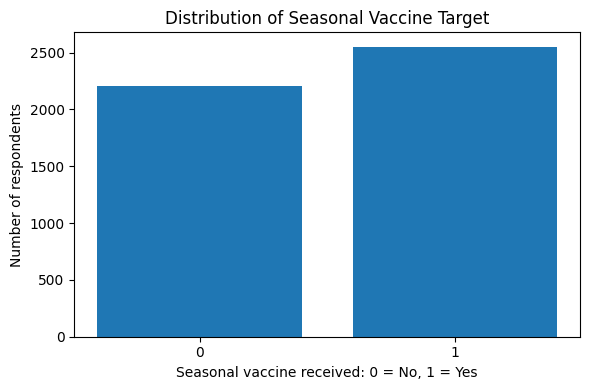

In [12]:
target_counts = train_df[TARGET].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    target_counts.index.astype(str),
    target_counts.values,
)

plt.title("Distribution of Seasonal Vaccine Target")
plt.xlabel("Seasonal vaccine received: 0 = No, 1 = Yes")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

In [13]:
missing_summary = (
    train_df
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .rename("missing_percentage")
    .to_frame()
)

print("Top 20 columns with missing values:")
display(missing_summary.head(20))

Top 20 columns with missing values:


,missing_percentage
employment_sector,48.654331
health_insurance,40.475189
income_poverty,16.610597
rent_or_own,8.010934
doctor_recc_seasonal,6.749369
education,5.677040
employment_status,5.656013
marital_status,5.571909
chronic_med_condition,3.952902
child_under_6_months,3.195963


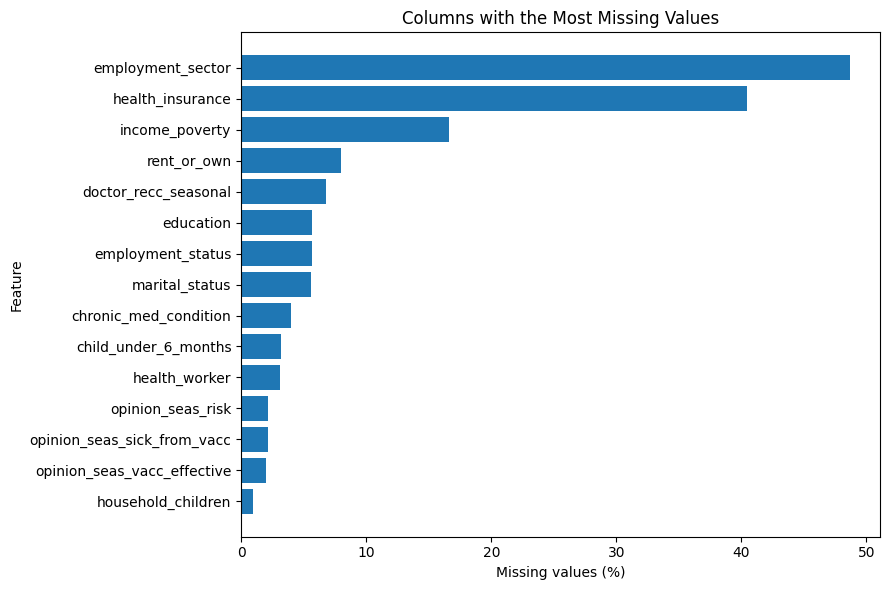

In [14]:
top_missing = (
    missing_summary
    .head(15)
    .sort_values("missing_percentage")
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_missing.index,
    top_missing["missing_percentage"],
)

plt.title("Columns with the Most Missing Values")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [15]:
X = train_df.drop(
    columns=[ID_COLUMN, TARGET]
)

y = train_df[TARGET].astype(int)

X_test = test_df.drop(
    columns=[ID_COLUMN]
)

test_ids = test_df[ID_COLUMN].copy()

print("Training features shape:", X.shape)
print("Target shape:", y.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (4756, 29)
Target shape: (4756,)
Testing features shape: (4749, 29)


In [16]:
categorical_columns = (
    X
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numeric_columns = [
    column
    for column in X.columns
    if column not in categorical_columns
]

print("Number of numeric columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

print("\nNumeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Number of numeric columns: 19
Number of categorical columns: 10

Numeric columns:
['flu_concern', 'flu_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'doctor_recc_seasonal', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'household_adults', 'household_children']

Categorical columns:
['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']


In [17]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "numeric_imputer",
            SimpleImputer(strategy="median"),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "categorical_imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "one_hot_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric_features",
            numeric_pipeline,
            numeric_columns,
        ),
        (
            "categorical_features",
            categorical_pipeline,
            categorical_columns,
        ),
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED,
)

print("Model-training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nValidation target proportions:")
display(y_valid.value_counts(normalize=True).sort_index())

Model-training rows: 3804
Validation rows: 952

Training target proportions:


,proportion
seasonal_vaccine,
0,0.463722
1,0.536278



Validation target proportions:


,proportion
seasonal_vaccine,
0,0.463235
1,0.536765


In [19]:
random_forest = RandomForestClassifier(
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced",
)

random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "model",
            random_forest,
        ),
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [20]:
parameter_grid = {
    "model__n_estimators": [
        150,
        300,
    ],
    "model__max_depth": [
        8,
        14,
        None,
    ],
    "model__min_samples_leaf": [
        1,
        3,
        6,
    ],
    "model__max_features": [
        "sqrt",
        "log2",
    ],
}

In [21]:
cross_validation = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED,
)

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=cross_validation,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True,
)

grid_search.fit(
    X_train,
    y_train,
)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(round(grid_search.best_score_, 4))

Fitting 4 folds for each of 36 candidates, totalling 144 fits

Best parameters:
{'model__max_depth': 14, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 300}

Best cross-validation ROC-AUC:
0.8439


In [24]:
tuning_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values(
        "rank_test_score"
    )
)

selected_tuning_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_leaf",
    "param_model__max_features",
]

display(
    tuning_results[
        selected_tuning_columns
    ].head(15)
)

tuning_results.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "random_forest_tuning_results.csv",
    ),
    index=False,
)

print("Tuning table saved.")

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
15,1,0.843878,0.004456,0.968568,300,14,3,sqrt
21,2,0.843749,0.004464,0.961563,300,14,3,log2
3,3,0.843613,0.002838,0.915472,300,8,3,sqrt
1,4,0.843555,0.002063,0.930736,300,8,1,sqrt
14,5,0.843547,0.005123,0.968127,150,14,3,sqrt
27,6,0.843396,0.004145,0.973377,300,None,3,sqrt
29,7,0.843380,0.003689,0.928453,300,None,6,sqrt
28,8,0.843304,0.003600,0.928184,150,None,6,sqrt
17,9,0.842972,0.003486,0.927785,300,14,6,sqrt
33,10,0.842969,0.004087,0.967358,300,None,3,log2


Tuning table saved.


In [25]:
best_random_forest = grid_search.best_estimator_

validation_probabilities = (
    best_random_forest
    .predict_proba(X_valid)[:, 1]
)

validation_predictions = (
    validation_probabilities >= 0.50
).astype(int)

validation_metrics = {
    "accuracy": accuracy_score(
        y_valid,
        validation_predictions,
    ),
    "balanced_accuracy": balanced_accuracy_score(
        y_valid,
        validation_predictions,
    ),
    "precision": precision_score(
        y_valid,
        validation_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_valid,
        validation_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_valid,
        validation_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_valid,
        validation_probabilities,
    ),
    "log_loss": log_loss(
        y_valid,
        validation_probabilities,
    ),
}

validation_metrics_df = pd.DataFrame(
    validation_metrics.items(),
    columns=[
        "metric",
        "value",
    ],
)

display(validation_metrics_df)

,metric,value
0,accuracy,0.766807
1,balanced_accuracy,0.766471
2,precision,0.789579
3,recall,0.771037
4,f1_score,0.780198
5,roc_auc,0.844660
6,log_loss,0.501829


In [26]:
print(
    classification_report(
        y_valid,
        validation_predictions,
        digits=4,
    )
)

              precision    recall  f1-score   support

           0     0.7417    0.7619    0.7517       441
           1     0.7896    0.7710    0.7802       511

    accuracy                         0.7668       952
   macro avg     0.7657    0.7665    0.7659       952
weighted avg     0.7674    0.7668    0.7670       952



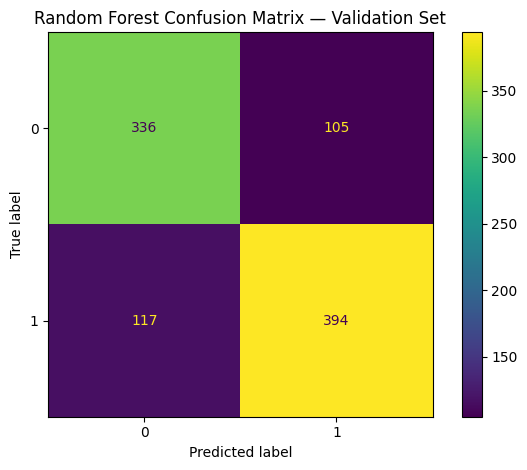

In [27]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    validation_predictions,
)

plt.title(
    "Random Forest Confusion Matrix — Validation Set"
)

plt.tight_layout()
plt.show()

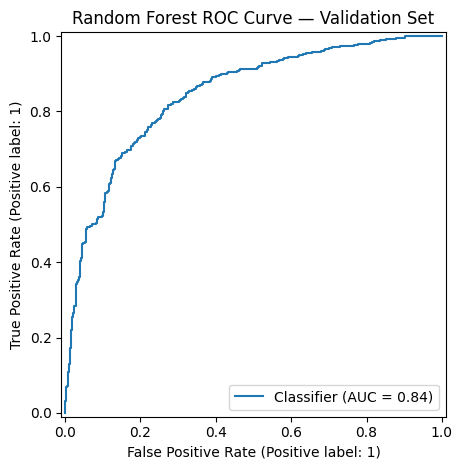

In [28]:
RocCurveDisplay.from_predictions(
    y_valid,
    validation_probabilities,
)

plt.title(
    "Random Forest ROC Curve — Validation Set"
)

plt.tight_layout()
plt.show()

In [29]:
validation_metrics_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "random_forest_validation_metrics.csv",
    ),
    index=False,
)

validation_results_df = pd.DataFrame(
    {
        "actual_target": y_valid.values,
        "predicted_probability": validation_probabilities,
        "predicted_label": validation_predictions,
    }
)

validation_results_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "random_forest_validation_predictions.csv",
    ),
    index=False,
)

print("Validation results saved.")

Validation results saved.


In [30]:
importance_result = permutation_importance(
    estimator=best_random_forest,
    X=X_valid,
    y=y_valid,
    scoring="roc_auc",
    n_repeats=8,
    random_state=SEED,
    n_jobs=-1,
)

feature_importance_df = pd.DataFrame(
    {
        "feature": X_valid.columns,
        "importance_mean": importance_result.importances_mean,
        "importance_std": importance_result.importances_std,
    }
)

feature_importance_df = (
    feature_importance_df
    .sort_values(
        "importance_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_importance_df.head(15))

,feature,importance_mean,importance_std
0,opinion_seas_risk,0.057656,0.008367
1,doctor_recc_seasonal,0.037079,0.003949
2,opinion_seas_vacc_effective,0.034858,0.002395
3,age_group,0.027010,0.005245
4,health_worker,0.005666,0.000772
5,flu_knowledge,0.004177,0.002629
6,household_children,0.003325,0.001303
7,employment_sector,0.002745,0.001215
8,chronic_med_condition,0.002432,0.001110
9,opinion_seas_sick_from_vacc,0.002158,0.000471


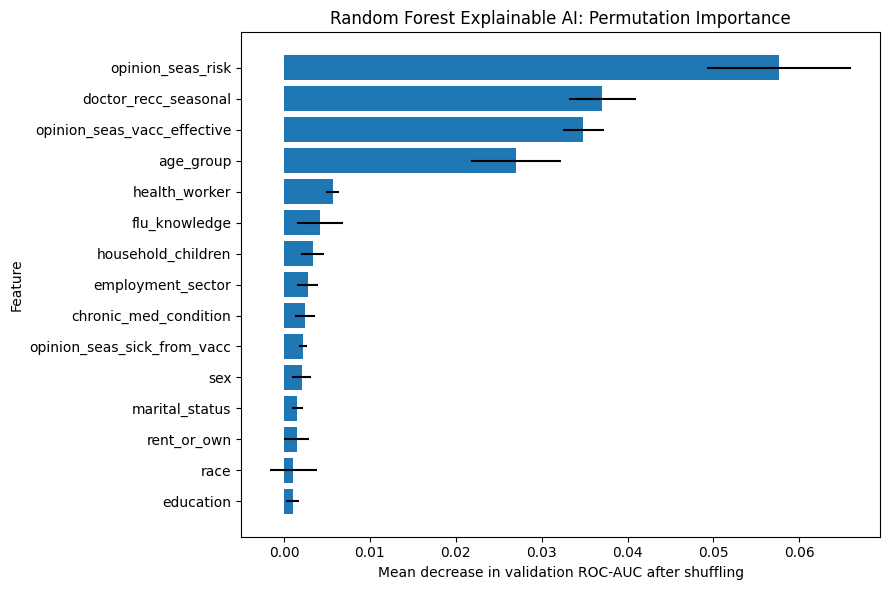

In [31]:
top_features = (
    feature_importance_df
    .head(15)
    .sort_values("importance_mean")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
)

plt.title(
    "Random Forest Explainable AI: Permutation Importance"
)

plt.xlabel(
    "Mean decrease in validation ROC-AUC after shuffling"
)

plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [32]:
feature_importance_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "random_forest_permutation_importance.csv",
    ),
    index=False,
)

print("Explainability results saved.")

Explainability results saved.


In [33]:
final_random_forest = grid_search.best_estimator_

final_random_forest.fit(
    X,
    y,
)

print("Final Random Forest trained on the complete training dataset.")

Final Random Forest trained on the complete training dataset.


In [34]:
test_probabilities = (
    final_random_forest
    .predict_proba(X_test)[:, 1]
)

test_hard_labels = (
    test_probabilities >= 0.50
).astype(int)

print("Number of testing predictions:", len(test_probabilities))
print("Minimum predicted probability:", test_probabilities.min())
print("Maximum predicted probability:", test_probabilities.max())

Number of testing predictions: 4749
Minimum predicted probability: 0.06447341278200215
Maximum predicted probability: 0.9820700454388208


In [35]:
probability_submission = pd.DataFrame(
    {
        ID_COLUMN: test_ids,
        TARGET: test_probabilities,
    }
)

probability_submission_path = os.path.join(
    OUTPUT_FOLDER,
    "random_forest_probabilities.csv",
)

probability_submission.to_csv(
    probability_submission_path,
    index=False,
)

print("Probability submission saved:")
print(probability_submission_path)

display(probability_submission.head())

Probability submission saved:
/content/drive/MyDrive/Dataset_A_Hackathon/random_forest_outputs/random_forest_probabilities.csv


,respondent_id,seasonal_vaccine
0,4757,0.472883
1,4758,0.731602
2,4759,0.771448
3,4760,0.638674
4,4761,0.195689


In [36]:
hard_label_submission = pd.DataFrame(
    {
        ID_COLUMN: test_ids,
        TARGET: test_hard_labels,
    }
)

hard_label_submission_path = os.path.join(
    OUTPUT_FOLDER,
    "random_forest_hard_labels.csv",
)

hard_label_submission.to_csv(
    hard_label_submission_path,
    index=False,
)

print("Hard-label alternative saved:")
print(hard_label_submission_path)

display(hard_label_submission.head())

Hard-label alternative saved:
/content/drive/MyDrive/Dataset_A_Hackathon/random_forest_outputs/random_forest_hard_labels.csv


,respondent_id,seasonal_vaccine
0,4757,0
1,4758,1
2,4759,1
3,4760,1
4,4761,0


In [37]:
best_parameters_df = pd.DataFrame(
    {
        "parameter": list(
            grid_search.best_params_.keys()
        ),
        "selected_value": list(
            grid_search.best_params_.values()
        ),
    }
)

best_parameters_df.to_csv(
    os.path.join(
        OUTPUT_FOLDER,
        "random_forest_best_parameters.csv",
    ),
    index=False,
)

display(best_parameters_df)

,parameter,selected_value
0,model__max_depth,14
1,model__max_features,sqrt
2,model__min_samples_leaf,3
3,model__n_estimators,300


In [55]:
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

In [56]:
classification_models = {
    "logistic_regression": LogisticRegression(
        C=0.8,
        max_iter=1200,
        class_weight="balanced",
        random_state=SEED,
    ),

    "decision_tree": DecisionTreeClassifier(
        max_depth=7,
        min_samples_leaf=12,
        class_weight="balanced",
        random_state=SEED,
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=14,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    ),

    "extra_trees": ExtraTreesClassifier(
        n_estimators=350,
        max_depth=16,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),

    "gradient_boosting": GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=8,
        random_state=SEED,
    ),

    "adaboost": AdaBoostClassifier(
        n_estimators=150,
        learning_rate=0.05,
        random_state=SEED,
    ),
}

print("Models ready:")
print(list(classification_models.keys()))

Models ready:
['logistic_regression', 'decision_tree', 'random_forest', 'extra_trees', 'gradient_boosting', 'adaboost']


In [57]:
model_results = []
trained_pipelines = {}

for model_name, model in classification_models.items():

    print("Training:", model_name)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                model,
            ),
        ]
    )

    pipeline.fit(
        X_train,
        y_train,
    )

    validation_probabilities = (
        pipeline
        .predict_proba(X_valid)[:, 1]
    )

    validation_predictions = (
        validation_probabilities >= 0.50
    ).astype(int)

    model_results.append(
        {
            "model": model_name,

            "accuracy": accuracy_score(
                y_valid,
                validation_predictions,
            ),

            "balanced_accuracy": balanced_accuracy_score(
                y_valid,
                validation_predictions,
            ),

            "precision": precision_score(
                y_valid,
                validation_predictions,
                zero_division=0,
            ),

            "recall": recall_score(
                y_valid,
                validation_predictions,
                zero_division=0,
            ),

            "f1_score": f1_score(
                y_valid,
                validation_predictions,
                zero_division=0,
            ),

            "roc_auc": roc_auc_score(
                y_valid,
                validation_probabilities,
            ),
        }
    )

    trained_pipelines[model_name] = pipeline

comparison_df = (
    pd.DataFrame(model_results)
    .sort_values(
        "balanced_accuracy",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(comparison_df)

Training: logistic_regression
Training: decision_tree
Training: random_forest
Training: extra_trees
Training: gradient_boosting
Training: adaboost


,model,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc
0,gradient_boosting,0.778361,0.776924,0.791829,0.796477,0.794146,0.847675
1,logistic_regression,0.775210,0.776007,0.806186,0.765166,0.785141,0.847718
2,random_forest,0.768908,0.769049,0.795132,0.767123,0.780876,0.845512
3,extra_trees,0.764706,0.764669,0.789899,0.765166,0.777336,0.839064
4,adaboost,0.758403,0.760041,0.797040,0.737769,0.766260,0.830154
5,decision_tree,0.733193,0.729724,0.739292,0.776908,0.757634,0.797376


In [58]:
top_five_models = (
    comparison_df
    .head(5)["model"]
    .tolist()
)

print("Top five standalone models:")
print(top_five_models)

binary_submission_folder = os.path.join(
    OUTPUT_FOLDER,
    "binary_model_submissions",
)

os.makedirs(
    binary_submission_folder,
    exist_ok=True,
)

submission_manifest = []

for rank, model_name in enumerate(
    top_five_models,
    start=1,
):

    print("Retraining:", model_name)

    final_pipeline = trained_pipelines[
        model_name
    ]

    final_pipeline.fit(
        X,
        y,
    )

    test_binary_predictions = (
        final_pipeline
        .predict(X_test)
        .astype(int)
    )

    output_filename = (
        f"{rank}_{model_name}_binary_labels.csv"
    )

    output_path = os.path.join(
        binary_submission_folder,
        output_filename,
    )

    submission_df = pd.DataFrame(
        {
            ID_COLUMN: test_ids,
            TARGET: test_binary_predictions,
        }
    )

    submission_df.to_csv(
        output_path,
        index=False,
    )

    submission_manifest.append(
        {
            "rank": rank,
            "model": model_name,
            "file": output_filename,
        }
    )

manifest_df = pd.DataFrame(
    submission_manifest
)

display(manifest_df)

print("Five binary prediction files created.")

Top five standalone models:
['gradient_boosting', 'logistic_regression', 'random_forest', 'extra_trees', 'adaboost']
Retraining: gradient_boosting
Retraining: logistic_regression
Retraining: random_forest
Retraining: extra_trees
Retraining: adaboost


,rank,model,file
0,1,gradient_boosting,1_gradient_boosting_binary_labels.csv
1,2,logistic_regression,2_logistic_regression_binary_labels.csv
2,3,random_forest,3_random_forest_binary_labels.csv
3,4,extra_trees,4_extra_trees_binary_labels.csv
4,5,adaboost,5_adaboost_binary_labels.csv


Five binary prediction files created.


In [59]:
import shutil

zip_path = shutil.make_archive(
    "/content/binary_model_submissions",
    "zip",
    binary_submission_folder,
)

print("ZIP created:")
print(zip_path)

from google.colab import files

files.download(
    zip_path
)

ZIP created:
/content/binary_model_submissions.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>